In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import shap

# Initialize JavaScript visualization context for SHAP interactive layers
shap.initjs()
sns.set_theme(style="whitegrid")
%matplotlib inline

print("✅ Explainability and governance environment initialized.")

✅ Explainability and governance environment initialized.


In [6]:
NOTEBOOK_DIR = Path(os.getcwd())
PROJECT_ROOT = NOTEBOOK_DIR.parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

# 1. Ingest validated partitions
train_df = pd.read_parquet(PROCESSED_DIR / "train.parquet")
test_df = pd.read_parquet(PROCESSED_DIR / "test.parquet")

# Drop unique identifier keys that carry zero weight gravity
if 'LoanID' in train_df.columns:
    train_df = train_df.drop(columns=['LoanID'])
if 'LoanID' in test_df.columns:
    test_df = test_df.drop(columns=['LoanID'])

X_train = train_df.drop(columns=['Default'])
y_train = train_df['Default']
X_audit = test_df.drop(columns=['Default'])
y_audit = test_df['Default']

# Isolate protected proxy attribute
X_train['is_young'] = (X_train['Age'] < 30).astype(int)
X_audit['is_young'] = (X_audit['Age'] < 30).astype(int)

# 2. Re-encode categorical features into numeric flags dynamically
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
if categorical_cols:
    X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
    X_audit = pd.get_dummies(X_audit, columns=categorical_cols, drop_first=True)
    # Re-align matrices to guarantee perfectly matching feature columns
    X_train, X_audit = X_train.align(X_audit, join='left', axis=1, fill_value=0)

# Convert any newly generated boolean flags to safe integers for XGBoost
X_train = X_train.astype({col: 'int8' for col in X_train.select_dtypes(include=['bool']).columns})
X_audit = X_audit.astype({col: 'int8' for col in X_audit.select_dtypes(include=['bool']).columns})

# 3. Calculate Sample Weights for the Fair Model
N = len(train_df)
n_fav = len(train_df[train_df['Default'] == 0])
n_unfav = len(train_df[train_df['Default'] == 1])
n_protected = len(train_df[train_df['Age'] < 30])
n_baseline = len(train_df[train_df['Age'] >= 30])
n_prot_fav = len(train_df[(train_df['Age'] < 30) & (train_df['Default'] == 0)])
n_prot_unfav = len(train_df[(train_df['Age'] < 30) & (train_df['Default'] == 1)])
n_base_fav = len(train_df[(train_df['Age'] >= 30) & (train_df['Default'] == 0)])
n_base_unfav = len(train_df[(train_df['Age'] >= 30) & (train_df['Default'] == 1)])

w_prot_fav = (n_protected * n_fav) / (N * n_prot_fav) if n_prot_fav > 0 else 1.0
w_prot_unfav = (n_protected * n_unfav) / (N * n_prot_unfav) if n_prot_unfav > 0 else 1.0
w_base_fav = (n_baseline * n_fav) / (N * n_base_fav) if n_base_fav > 0 else 1.0
w_base_unfav = (n_baseline * n_unfav) / (N * n_base_unfav) if n_base_unfav > 0 else 1.0

train_weights = np.ones(N)
train_weights[(train_df['Age'] < 30) & (train_df['Default'] == 0)] = w_prot_fav
train_weights[(train_df['Age'] < 30) & (train_df['Default'] == 1)] = w_prot_unfav
train_weights[(train_df['Age'] >= 30) & (train_df['Default'] == 0)] = w_base_fav
train_weights[(train_df['Age'] >= 30) & (train_df['Default'] == 1)] = w_base_unfav

# 4. Spin up models for explainability mapping
from xgboost import XGBClassifier
base_model = XGBClassifier(random_state=42, eval_metric='logloss', n_estimators=100)
base_model.fit(X_train, y_train)

fair_model = XGBClassifier(random_state=42, eval_metric='logloss', n_estimators=100)
fair_model.fit(X_train, y_train, sample_weight=train_weights)

print(f"🔬 Evaluation matrices verified: {X_audit.shape[0]:,} rows across {X_audit.shape[1]} active numeric features.")

🔬 Evaluation matrices verified: 51,070 rows across 25 active numeric features.


In [7]:
print("🧮 Computing SHAP values for the Baseline Model...")
explainer_base = shap.TreeExplainer(base_model)
shap_values_base = explainer_base(X_audit)

print("🧮 Computing SHAP values for the Mitigated (Fair) Model...")
explainer_fair = shap.TreeExplainer(fair_model)
shap_values_fair = explainer_fair(X_audit)

print("✅ Game-theoretic feature attributions successfully calculated.")

🧮 Computing SHAP values for the Baseline Model...
🧮 Computing SHAP values for the Mitigated (Fair) Model...
✅ Game-theoretic feature attributions successfully calculated.


📊 [Model 1] Baseline Global Feature Importance Profile:


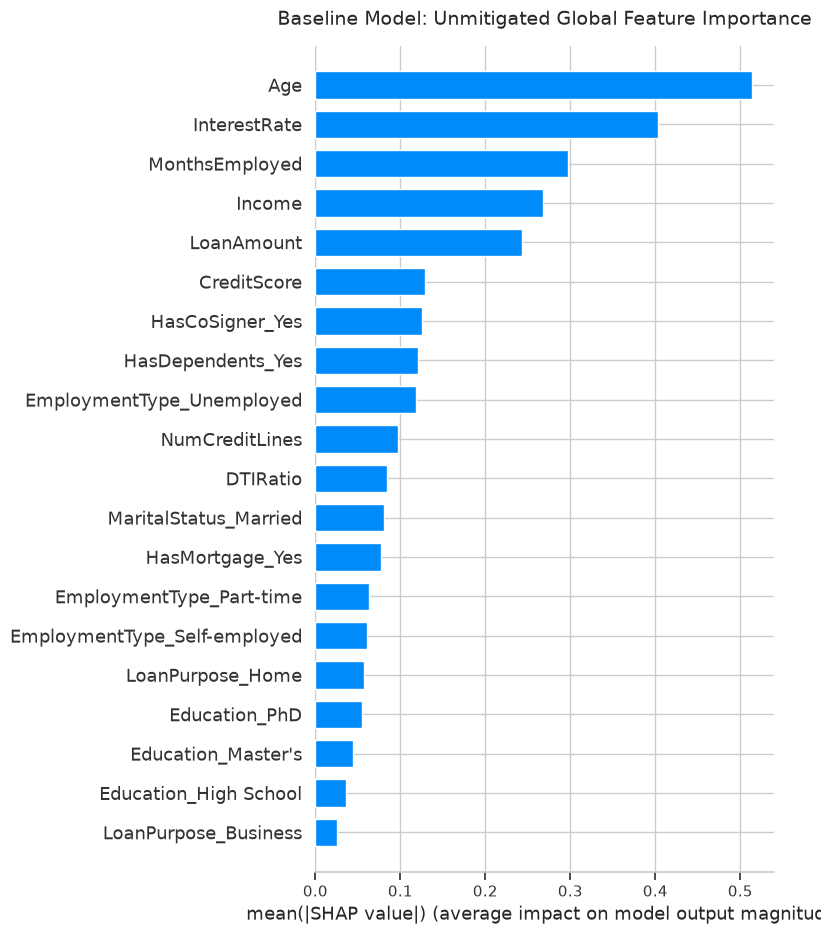


📊 [Model 2] Mitigated (Fair) Global Feature Importance Profile:


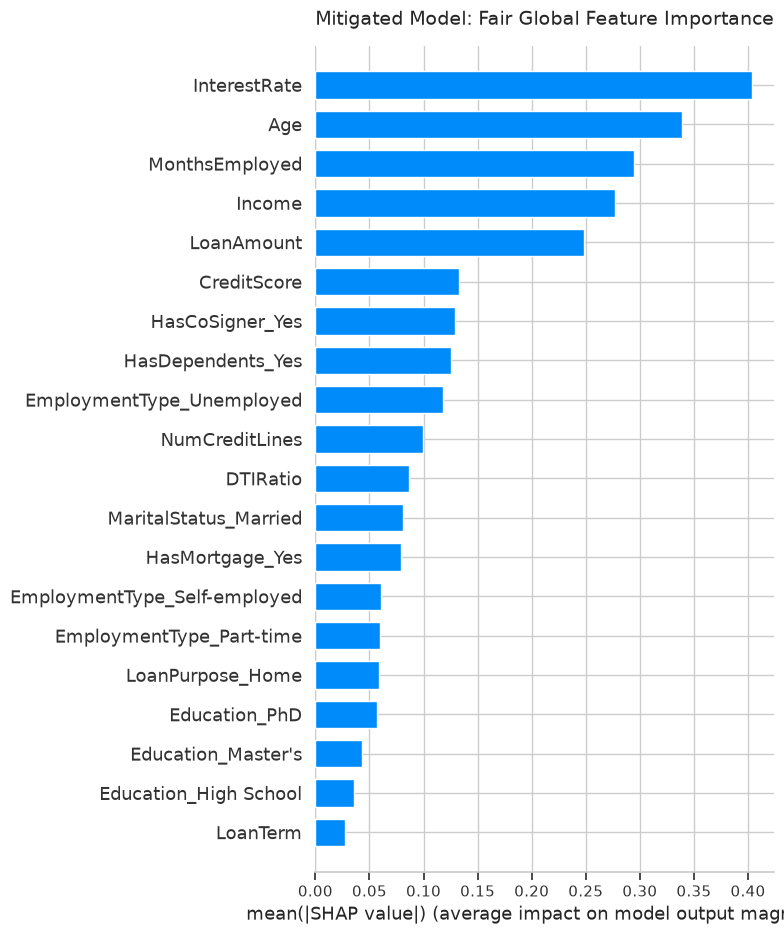

In [8]:
print("📊 [Model 1] Baseline Global Feature Importance Profile:")
plt.figure(figsize=(10, 5))
shap.summary_plot(shap_values_base, X_audit, plot_type="bar", show=False)
plt.title("Baseline Model: Unmitigated Global Feature Importance", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

print("\n📊 [Model 2] Mitigated (Fair) Global Feature Importance Profile:")
plt.figure(figsize=(10, 5))
shap.summary_plot(shap_values_fair, X_audit, plot_type="bar", show=False)
plt.title("Mitigated Model: Fair Global Feature Importance", fontsize=14, pad=15)
plt.tight_layout()
plt.show()